Вам предстоит решить задачу классификации сложных цветных изображений — датасет **CIFAR-10**.
В нем 10 классов: самолеты, автомобили, птицы, кошки, олени, собаки, лягушки, лошади, корабли, грузовики.

**Ваша цель:** Пробить "потолок" точности (`accuracy`) в **50%** на тестовой выборке.
**Главное правило:** Запрещено использовать любые слои, кроме `Dense`, `Dropout`, `Input` и слоев регуляризации. Никаких сверточных нейросетей (CNN)! Только полносвязные сети.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks

# Вспомогательная функция для отрисовки графиков
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Validation Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()

    ax2.plot(history.history['accuracy'], label='Train Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()

    plt.show()

### Шаг 1: Загрузка и подготовка данных
Изображения цветные, размер 32x32 пикселя, 3 канала (RGB).
1. Загрузите датасет CIFAR-10.
2. "Распрямите" изображения (Flatten) в плоский вектор. Какова будет его размерность?
3. Масштабируйте данные (от 0 до 1).
4. Закодируйте метки классов (y) методом One-Hot Encoding.

In [ ]:
# Загрузка данных
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
# Flatten изображений
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

In [ ]:
# Масштабирование
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [ ]:
# One-Hot Encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [ ]:
# Проверка размеров
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(50000, 3072)
(10000, 3072)
(50000, 10)
(10000, 10)


### Шаг 2: Модель "Слабое звено" (Недообучение)
Давайте посмотрим, что будет, если дать сложной задаче слишком простую модель.
1. Создайте сеть всего с одним скрытым слоем на **32 нейрона** (активация `relu`).
2. Добавьте выходной слой. *Внимание! Подумайте, какая функция активации и loss-функция нужны для 10 классов.*
3. Обучите на 15 эпохах.
4. Постройте графики. Сделайте выводы: хватает ли емкости этой сети, чтобы уловить закономерности в цветных фото?

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1660 - loss: 2.2268 - val_accuracy: 0.2067 - val_loss: 2.1554
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2140 - loss: 2.1132 - val_accuracy: 0.2306 - val_loss: 2.0871
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2318 - loss: 2.0604 - val_accuracy: 0.2357 - val_loss: 2.0474
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2396 - loss: 2.0292 - val_accuracy: 0.2427 - val_loss: 2.0282
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2433 - loss: 2.0145 - val_accuracy: 0.2471 - val_loss: 2.0158
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2442 - loss: 2.0058 - val_accuracy: 0.2188 - val_loss: 2.0641
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2485 - loss: 1.9957 - val_accuracy: 0.2506 - val_loss: 2.0032
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2481 - loss: 1.9914 - val_accuracy: 0.

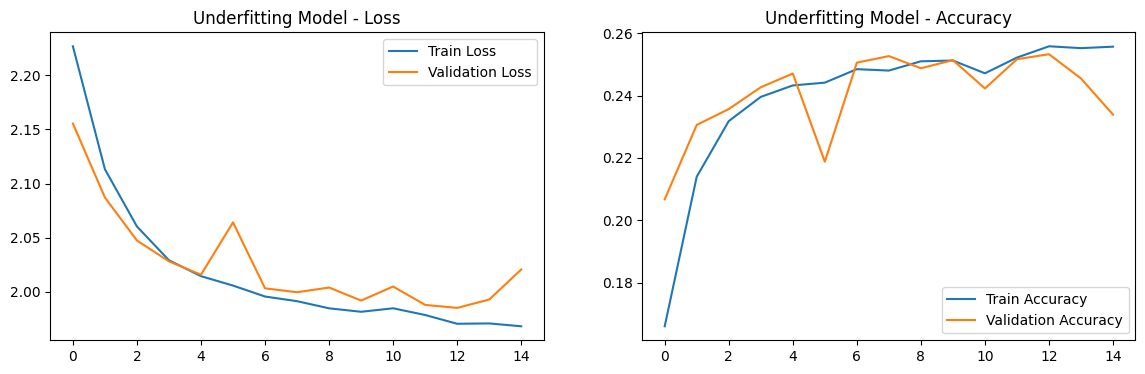

In [ ]:
# Модель с недообучением
model_underfit = keras.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Компиляция
model_underfit.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Обучение
history_underfit = model_underfit.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2
)

# Графики
plot_history(history_underfit, "Underfitting Model")

### Шаг 3: Модель "Зубрила" (Переобучение)
Простая модель не справилась (метрики застряли на ~30%). Дадим сети больше мощности!
1. Постройте глубокую полносвязную сеть (например, скрытые слои на **1024, 512 и 256 нейронов**).
2. **Не используйте** Dropout или регуляризацию.
3. Обучите на 25 эпохах.
4. Постройте графики. **Вопрос для размышления:** На какой эпохе сеть перестала учиться обобщать и начала просто "зазубривать" тренировочные данные? Как вы это поняли по графику Loss?

Epoch 1/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 86ms/step - accuracy: 0.3029 - loss: 1.9453 - val_accuracy: 0.3351 - val_loss: 1.8387
Epoch 2/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 82ms/step - accuracy: 0.3810 - loss: 1.7153 - val_accuracy: 0.4072 - val_loss: 1.6626
Epoch 3/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 92ms/step - accuracy: 0.4230 - loss: 1.6132 - val_accuracy: 0.4061 - val_loss: 1.6525
Epoch 4/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 88ms/step - accuracy: 0.4466 - loss: 1.5464 - val_accuracy: 0.4429 - val_loss: 1.5692
Epoch 5/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 97ms/step - accuracy: 0.4627 - loss: 1.4981 - val_accuracy: 0.4387 - val_loss: 1.5841
Epoch 6/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 106ms/step - accuracy: 0.4762 - loss: 1.4643 - val_accuracy: 0.4565 - val_loss: 1.5284
Epoch 7/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 101ms/step - accuracy: 0.4884 - loss: 1.4289 - val_accuracy: 0.4703 - val_loss: 1.5136
Epoch 8/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 101ms/step - accuracy: 0.4976 - loss: 1.3981

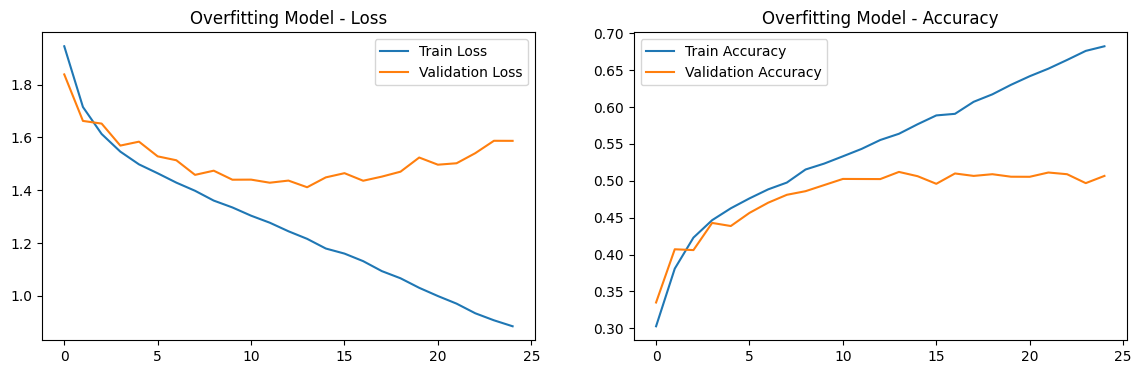

In [ ]:
# Модель с переобучением
model_overfit = keras.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(1024, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Компиляция
model_overfit.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Обучение
history_overfit = model_overfit.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=128,
    validation_split=0.2
)

# Графики
plot_history(history_overfit, "Overfitting Model")

### Шаг 4: Вызываем подкрепление (Callbacks & Regularization)

Теперь применим весь арсенал. Создайте новую архитектуру, взяв за основу сеть из Шага 3, но добавив инструменты удержания:
1. **Dropout**: Добавьте слои `Dropout` (например, 0.3 или 0.4) после крупных `Dense` слоев.
2. **L2 Регуляризация**: (Опционально) добавьте `kernel_regularizer='l2'` в один из слоев.
3. **Callbacks**: При вызове метода `.fit()` передайте список из трех коллбэков:
   - `EarlyStopping`: остановка, если `val_accuracy` не растет 8 эпох (`restore_best_weights=False`, т.к. будем сохранять чекпоинтом).
   - `ReduceLROnPlateau`: уменьшение learning rate (factor=0.5), если метрика застряла на плато на 3 эпохи.
   - `ModelCheckpoint`: сохраняйте **только лучшие** веса в файл `best_cifar10_model.keras`.
4. Запустите обучение на 70 эпох. Коллбэки сами остановят процесс в нужный момент.

Epoch 1/70
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.1769 - loss: 2.4080
Epoch 1: val_accuracy improved from None to 0.28820, saving model to best_cifar10_model.keras

Epoch 1: finished saving model to best_cifar10_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 126ms/step - accuracy: 0.2177 - loss: 2.2237 - val_accuracy: 0.2882 - val_loss: 2.0439 - learning_rate: 0.0010
Epoch 2/70
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.2631 - loss: 2.0486
Epoch 2: val_accuracy improved from 0.28820 to 0.33030, saving model to best_cifar10_model.keras

Epoch 2: finished saving model to best_cifar10_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 126ms/step - accuracy: 0.2706 - loss: 2.0259 - val_accuracy: 0.3303 - val_loss: 1.9308 - learning_rate: 0.0010
Epoch 3/70
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.2889 - loss: 1.9664
Epoch 3: val_accuracy did not improve from 0.33030
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 125ms/step - accuracy: 0.2904 - loss: 1.9564 - val_ac

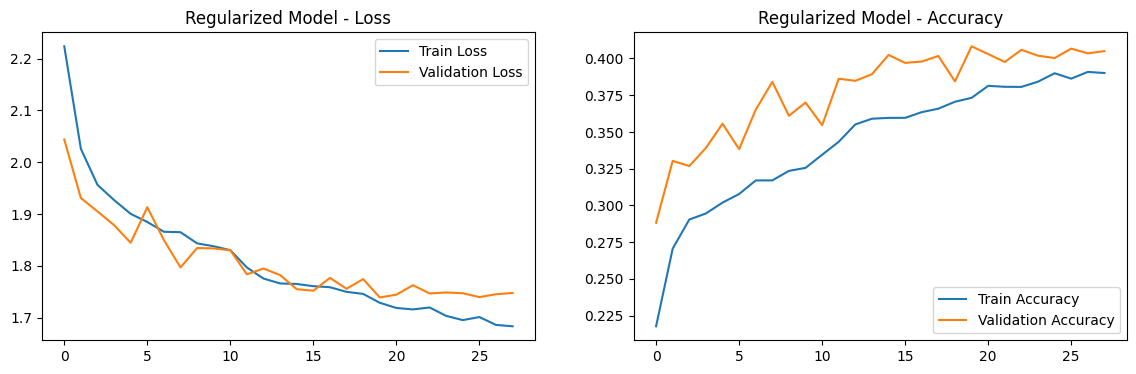

In [ ]:
from tensorflow.keras import regularizers

model_regularized = keras.Sequential([

    layers.Input(shape=(3072,)),
    layers.Dense(1024, activation='relu',kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

model_regularized.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=False
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

checkpoint = callbacks.ModelCheckpoint(
    'best_cifar10_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history_regularized = model_regularized.fit(
    X_train,
    y_train,
    epochs=70,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

plot_history(history_regularized, "Regularized Model")

### Шаг 5: Оценка результата
1. Загрузите лучшие веса из сохраненного файла (`keras.models.load_model`).
2. Сделайте `.predict()` на тестовой выборке (`X_test`).
3. Выведите итоговое значение `accuracy_score`. Смогли ли вы преодолеть барьер в 50%?
4. Напишите краткий вывод: какой инструмент по вашему мнению оказал наибольшее влияние на результат?

In [ ]:
# загрузка лучшей модели
best_model = keras.models.load_model("best_cifar10_model.keras")

# предсказания
y_pred_probs = best_model.predict(X_test)

# перевод вероятностей в классы
y_pred = np.argmax(y_pred_probs, axis=1)

# перевод one-hot обратно в метки
y_true = np.argmax(y_test, axis=1)

# вычисление accuracy
test_accuracy = accuracy_score(y_true, y_pred)

print("Test accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step
Test accuracy: 0.4184


# Вывод

По моему мнению, наибольшее влияние на итоговый результат оказали слои Dropout. Они снижают переобучение, случайно отключая часть нейронов, что заставляет модель учить более устойчивые и обобщающие признаки.

Также важную роль сыграли callback-функции, которые позволили остановить обучение до начала сильного переобучения и улучшить сходимость